In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [17]:
train_df  = pd.read_csv("train_play.csv")
display(train_df.head())
print(train_df.shape)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


(2190, 13)


In [59]:
train_df.isnull().sum().sort_values(ascending=False)
display(train_df)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


### Visualization

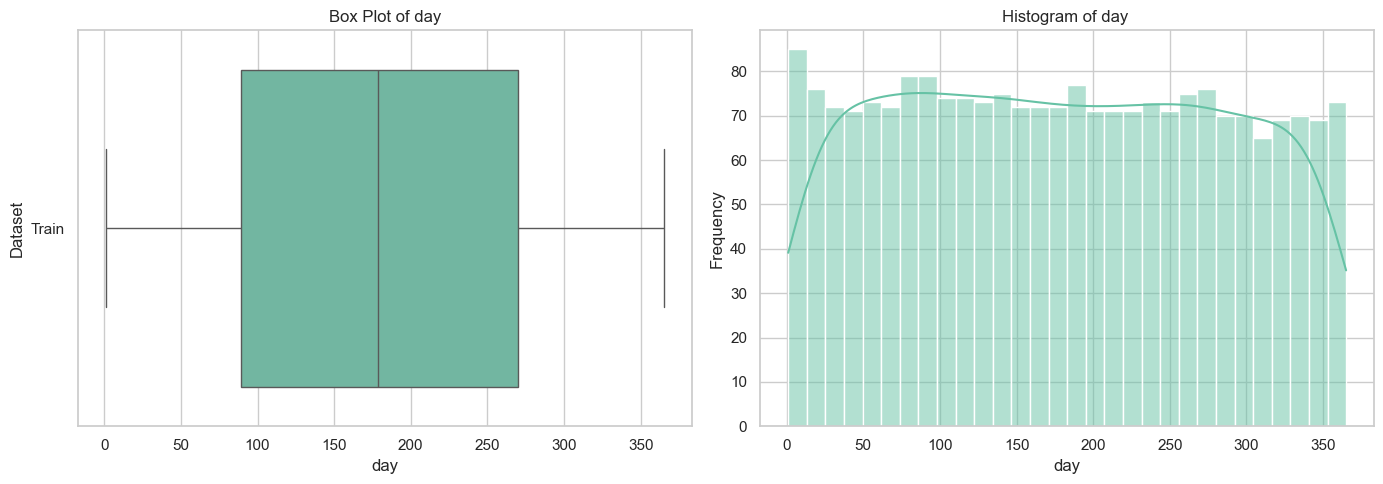

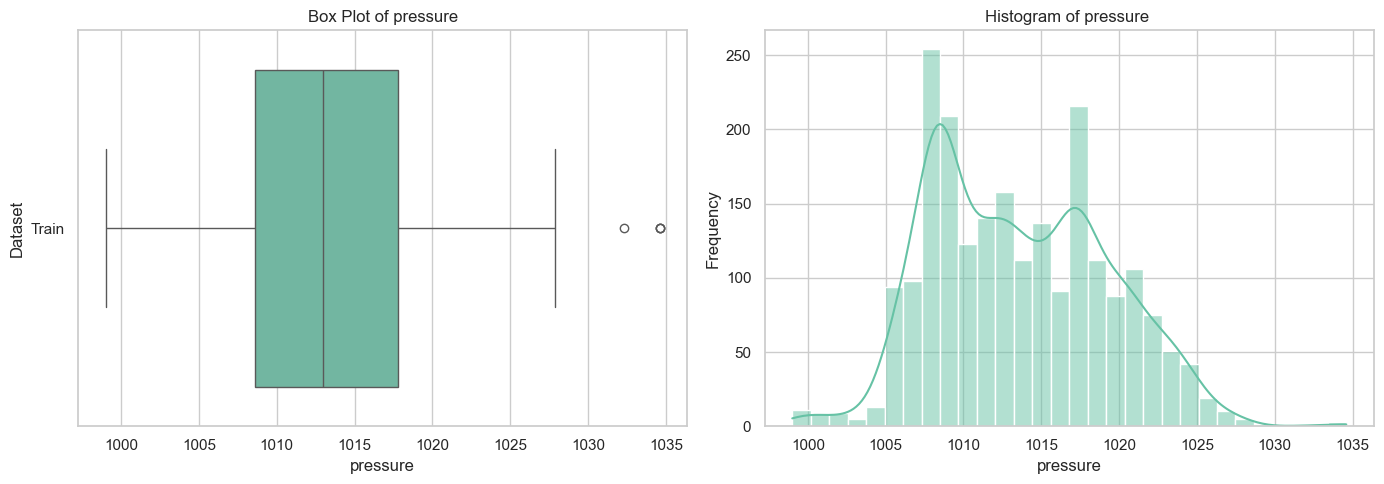

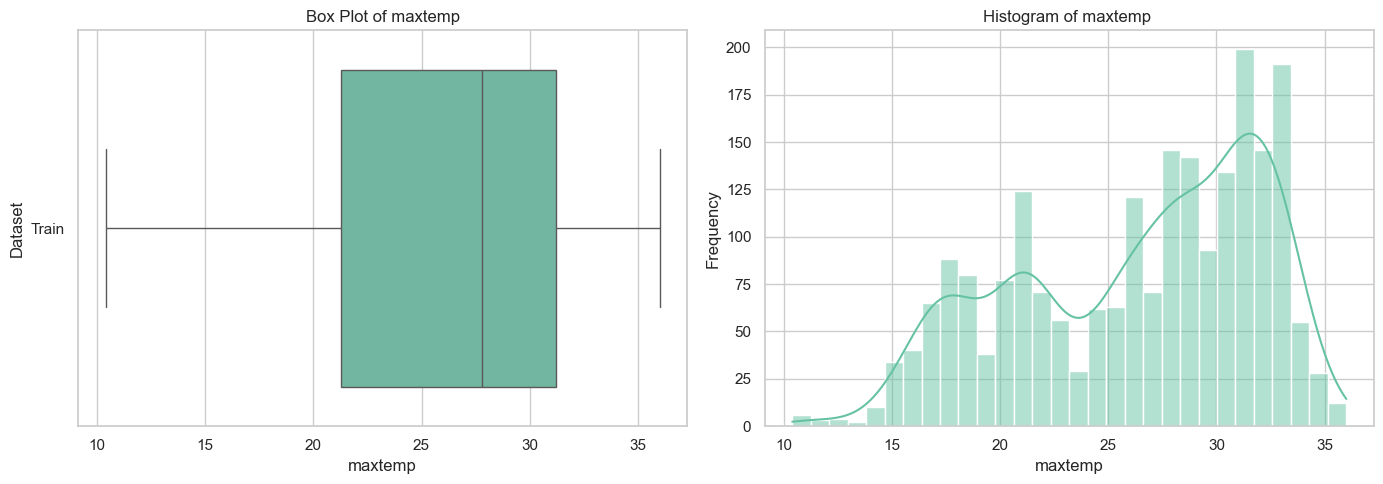

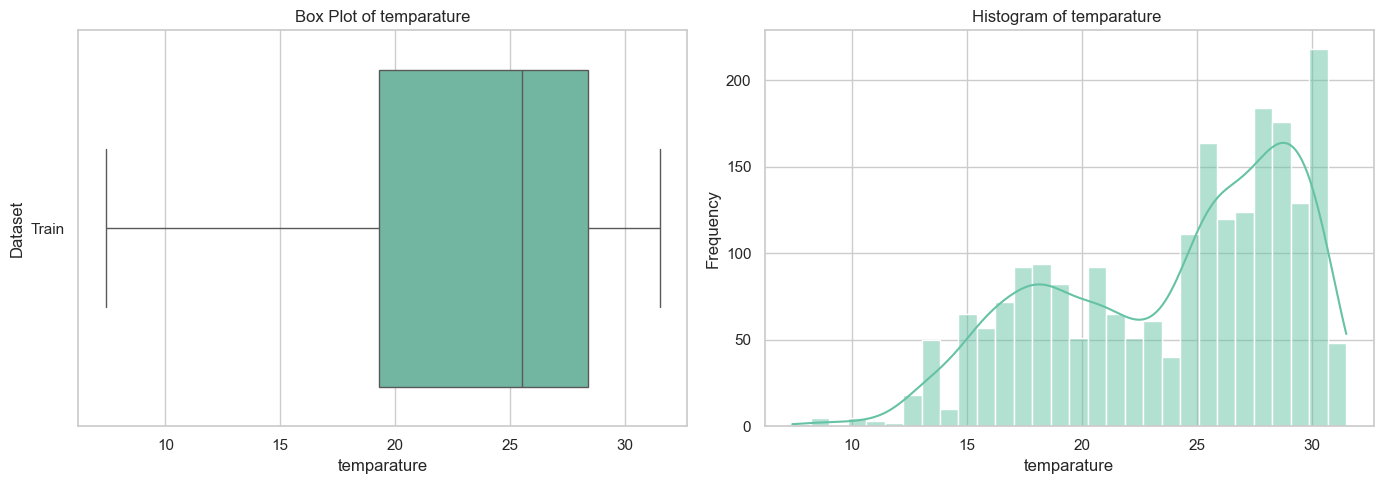

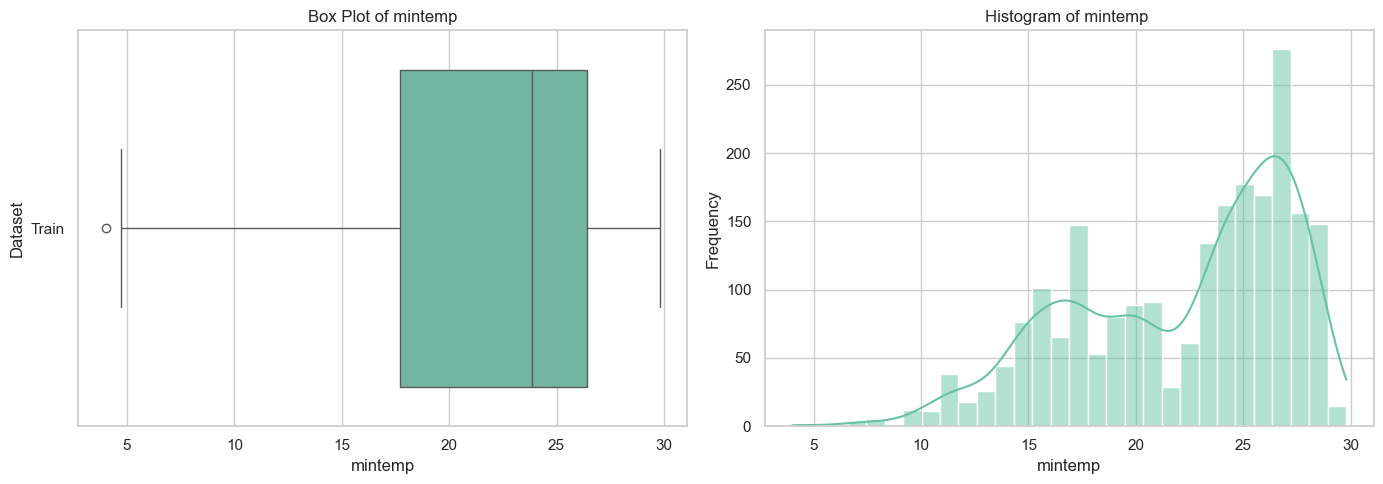

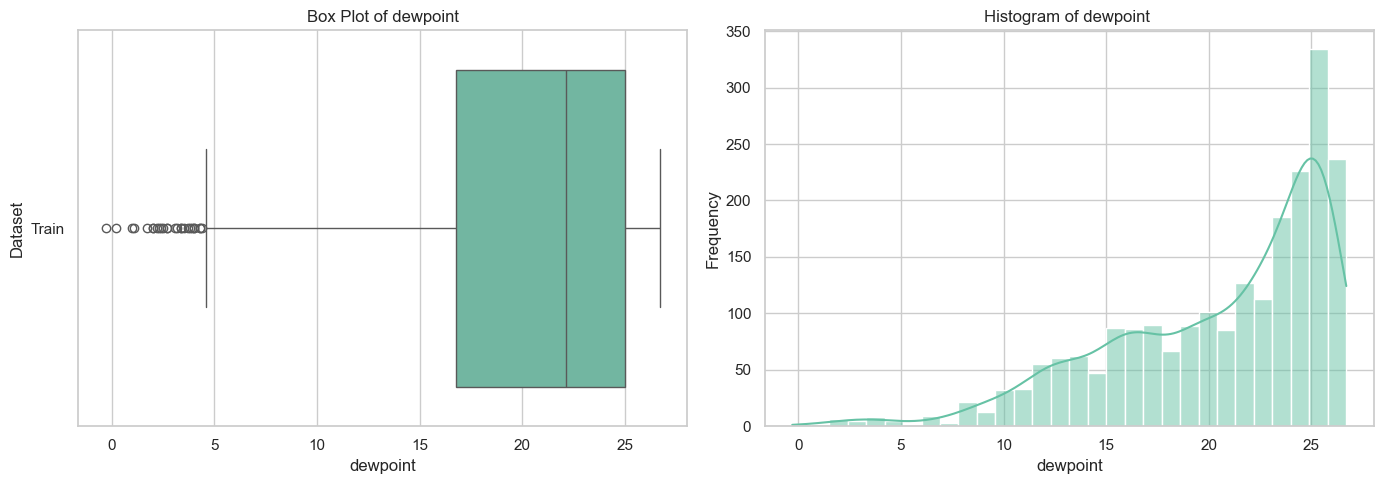

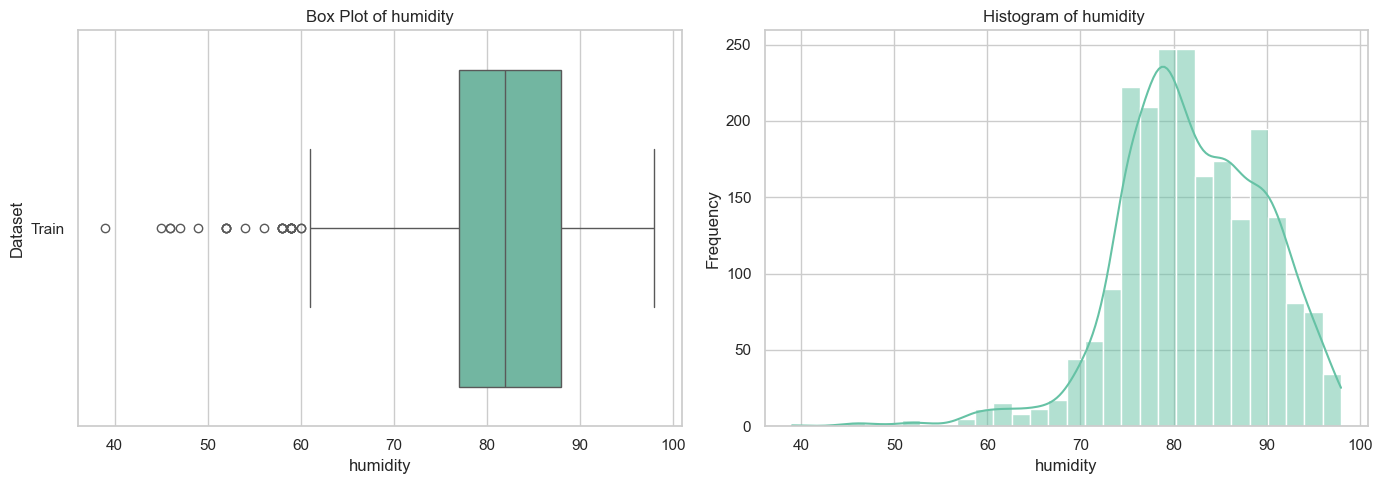

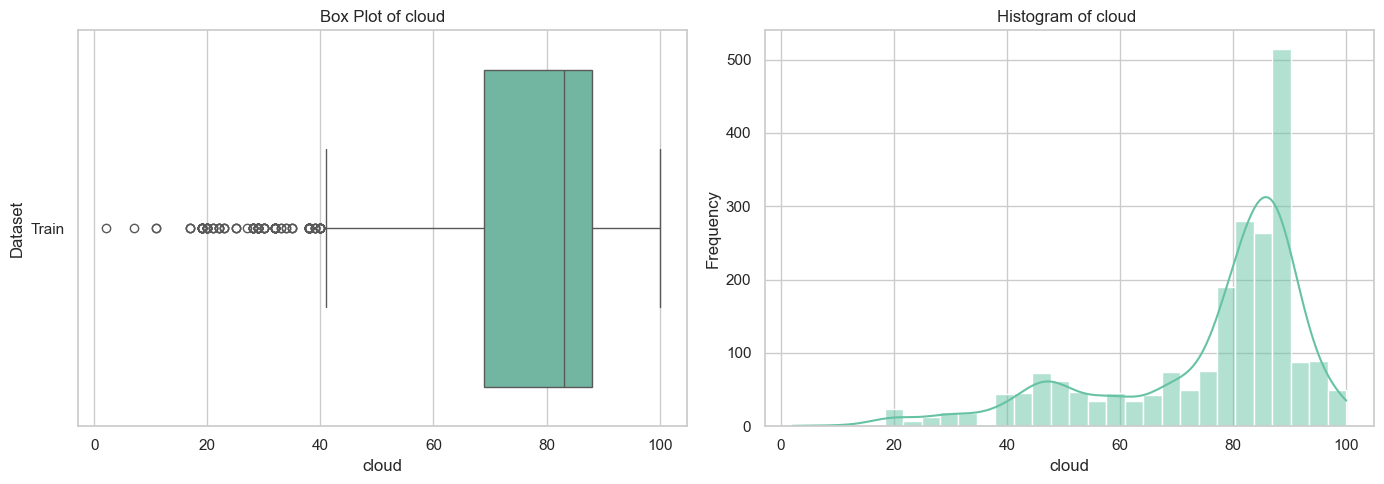

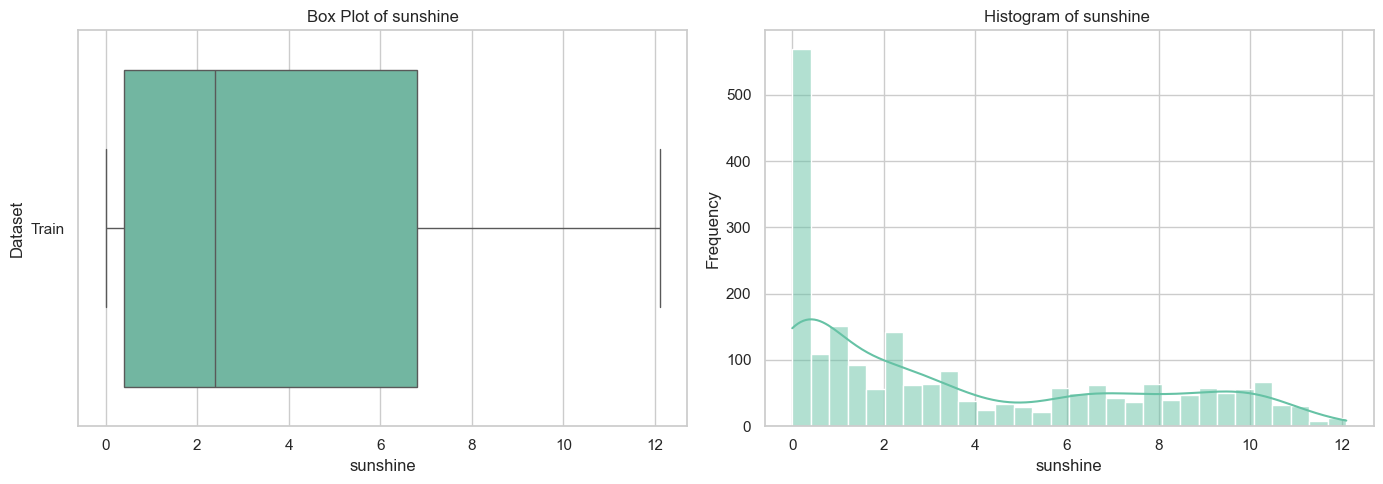

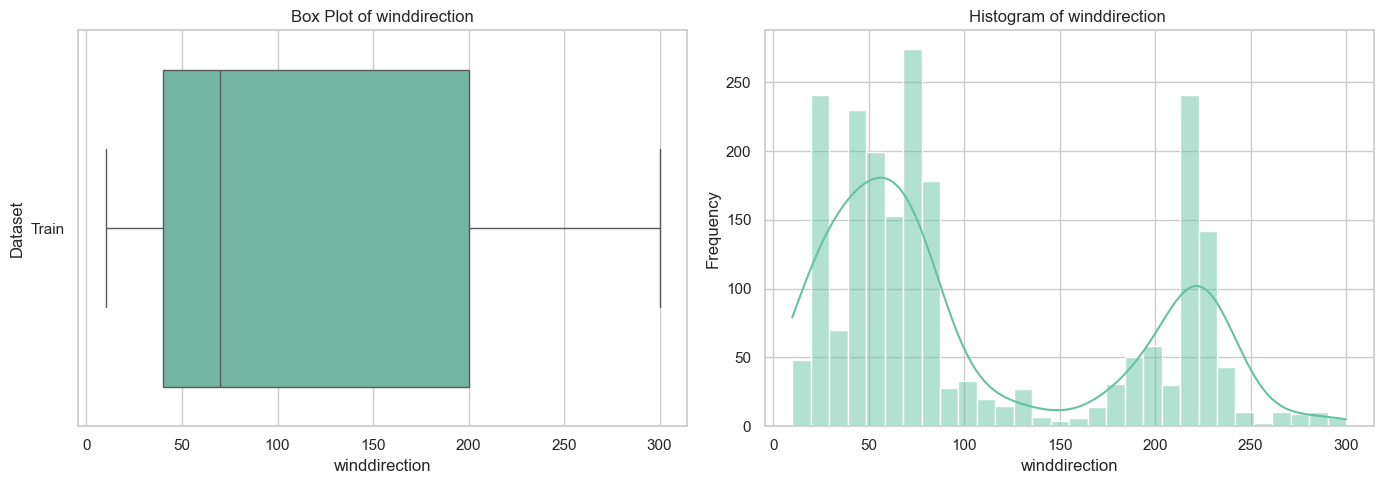

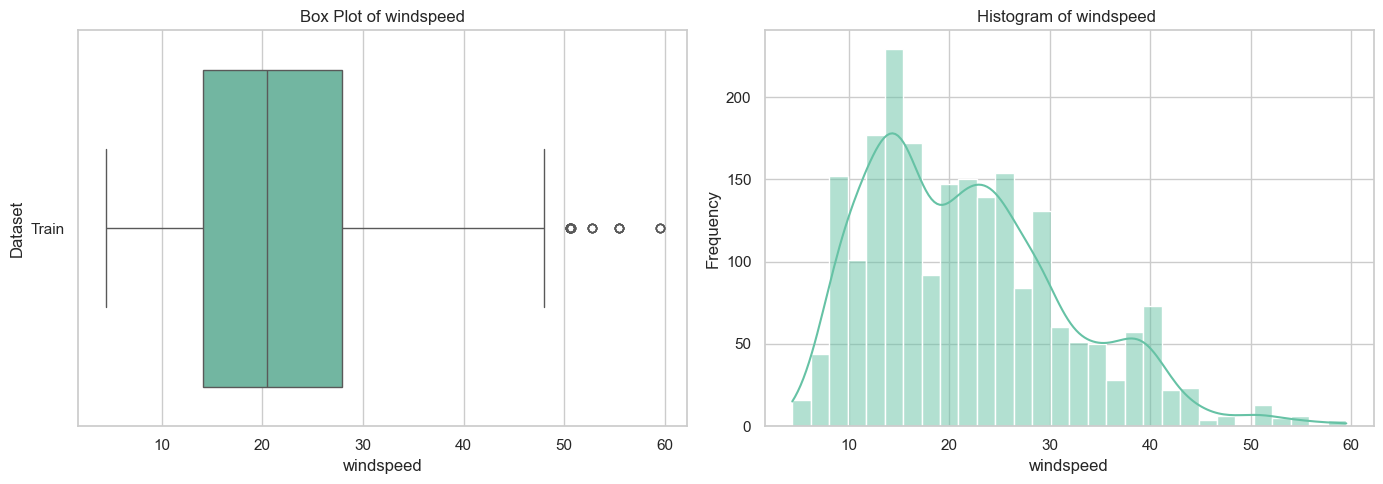

In [67]:
# Custom palette for the plots
custom_color = ['#66c2a5']

# Extract the names of the numerical columns as a list from train_df
numerical_columns = ["day","pressure","maxtemp","temparature","mintemp","dewpoint","humidity","cloud","sunshine",
                     "winddirection","windspeed"]

def plots_frequency(variable):
    # Set the seaborn theme for plots
    sns.set_theme(style="whitegrid")
    
    # Create a copy of train_df and add a column to label the dataset
    train_temp = train_df.copy()
    train_temp["Dataset"] = "Train"
    
    # Create two subplots side by side (one row, two columns)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Box Plot ---
    sns.boxplot(data=train_temp, x=variable, y="Dataset", palette=custom_color, ax=axes[0])
    axes[0].set_xlabel(variable)
    axes[0].set_title(f"Box Plot of {variable}")
    
    # --- Histogram ---
    sns.histplot(data=train_temp, x=variable, color=custom_color[0], kde=True, bins=30,  ax=axes[1])
    axes[1].set_xlabel(variable)
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"Histogram of {variable} ")
    
    # Adjust spacing and display the plot
    plt.tight_layout()
    plt.show()

# Loop through each numerical variable and generate the plots
for variable in numerical_columns:
    plots_frequency(variable)

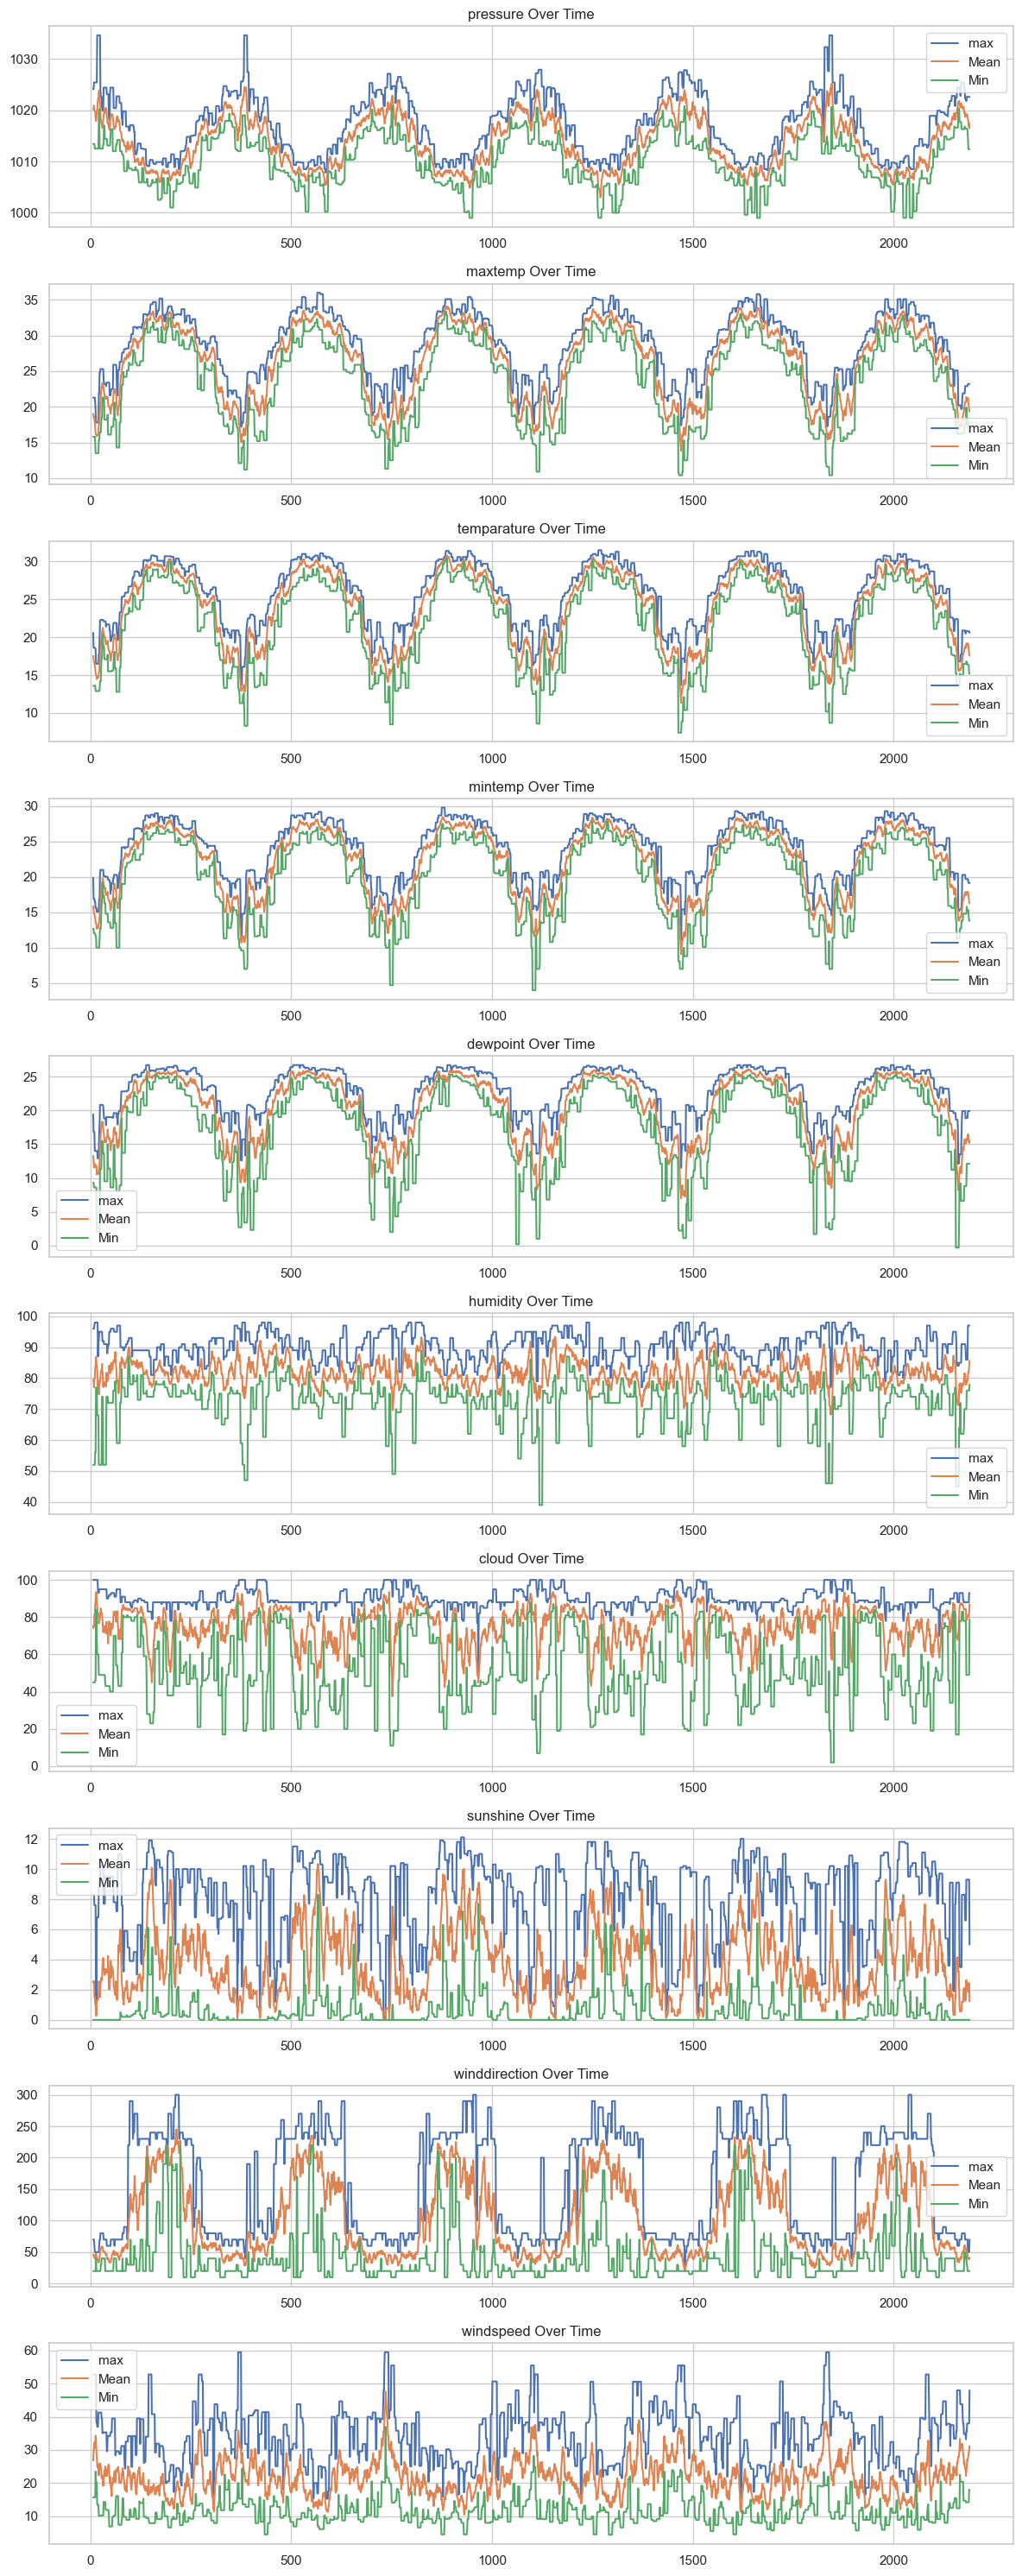

In [95]:
# Extract the names of the numerical columns as a list from train_df
numerical_column = ["pressure","maxtemp","temparature","mintemp","dewpoint","humidity","cloud","sunshine",
                     "winddirection","windspeed"]

fig, axes = plt.subplots(len(numerical_column), 1, figsize=(12, len(numerical_column) * 3))
train_copy = train_df.copy()
for i, var in enumerate(numerical_column):
    ax=axes[i]

    rolling_data = train_copy[var].rolling(window=8).agg(["max","mean","min"])

    #plot forevery aggregation ain the same subplots

    ax.plot(rolling_data["max"],label="max",color="C0")
    ax.plot(rolling_data["mean"], label="Mean", color="C1")
    ax.plot(rolling_data["min"],  label="Min",  color="C2")
    
    # 5) Set title and legend
    ax.set_title(f"{var} Over Time")
    ax.legend()

# 6) Adjust spacing and show
plt.tight_layout()
plt.show()

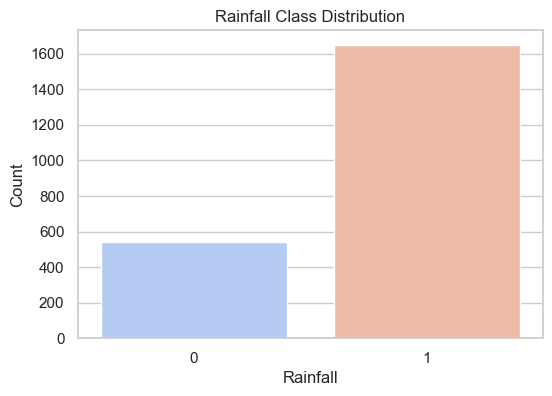

In [97]:
# Target variable
plt.figure(figsize=(6,4))
sns.countplot(x=train_copy['rainfall'], palette='coolwarm')
plt.title('Rainfall Class Distribution')
plt.xlabel('Rainfall')
plt.ylabel('Count')
plt.show()

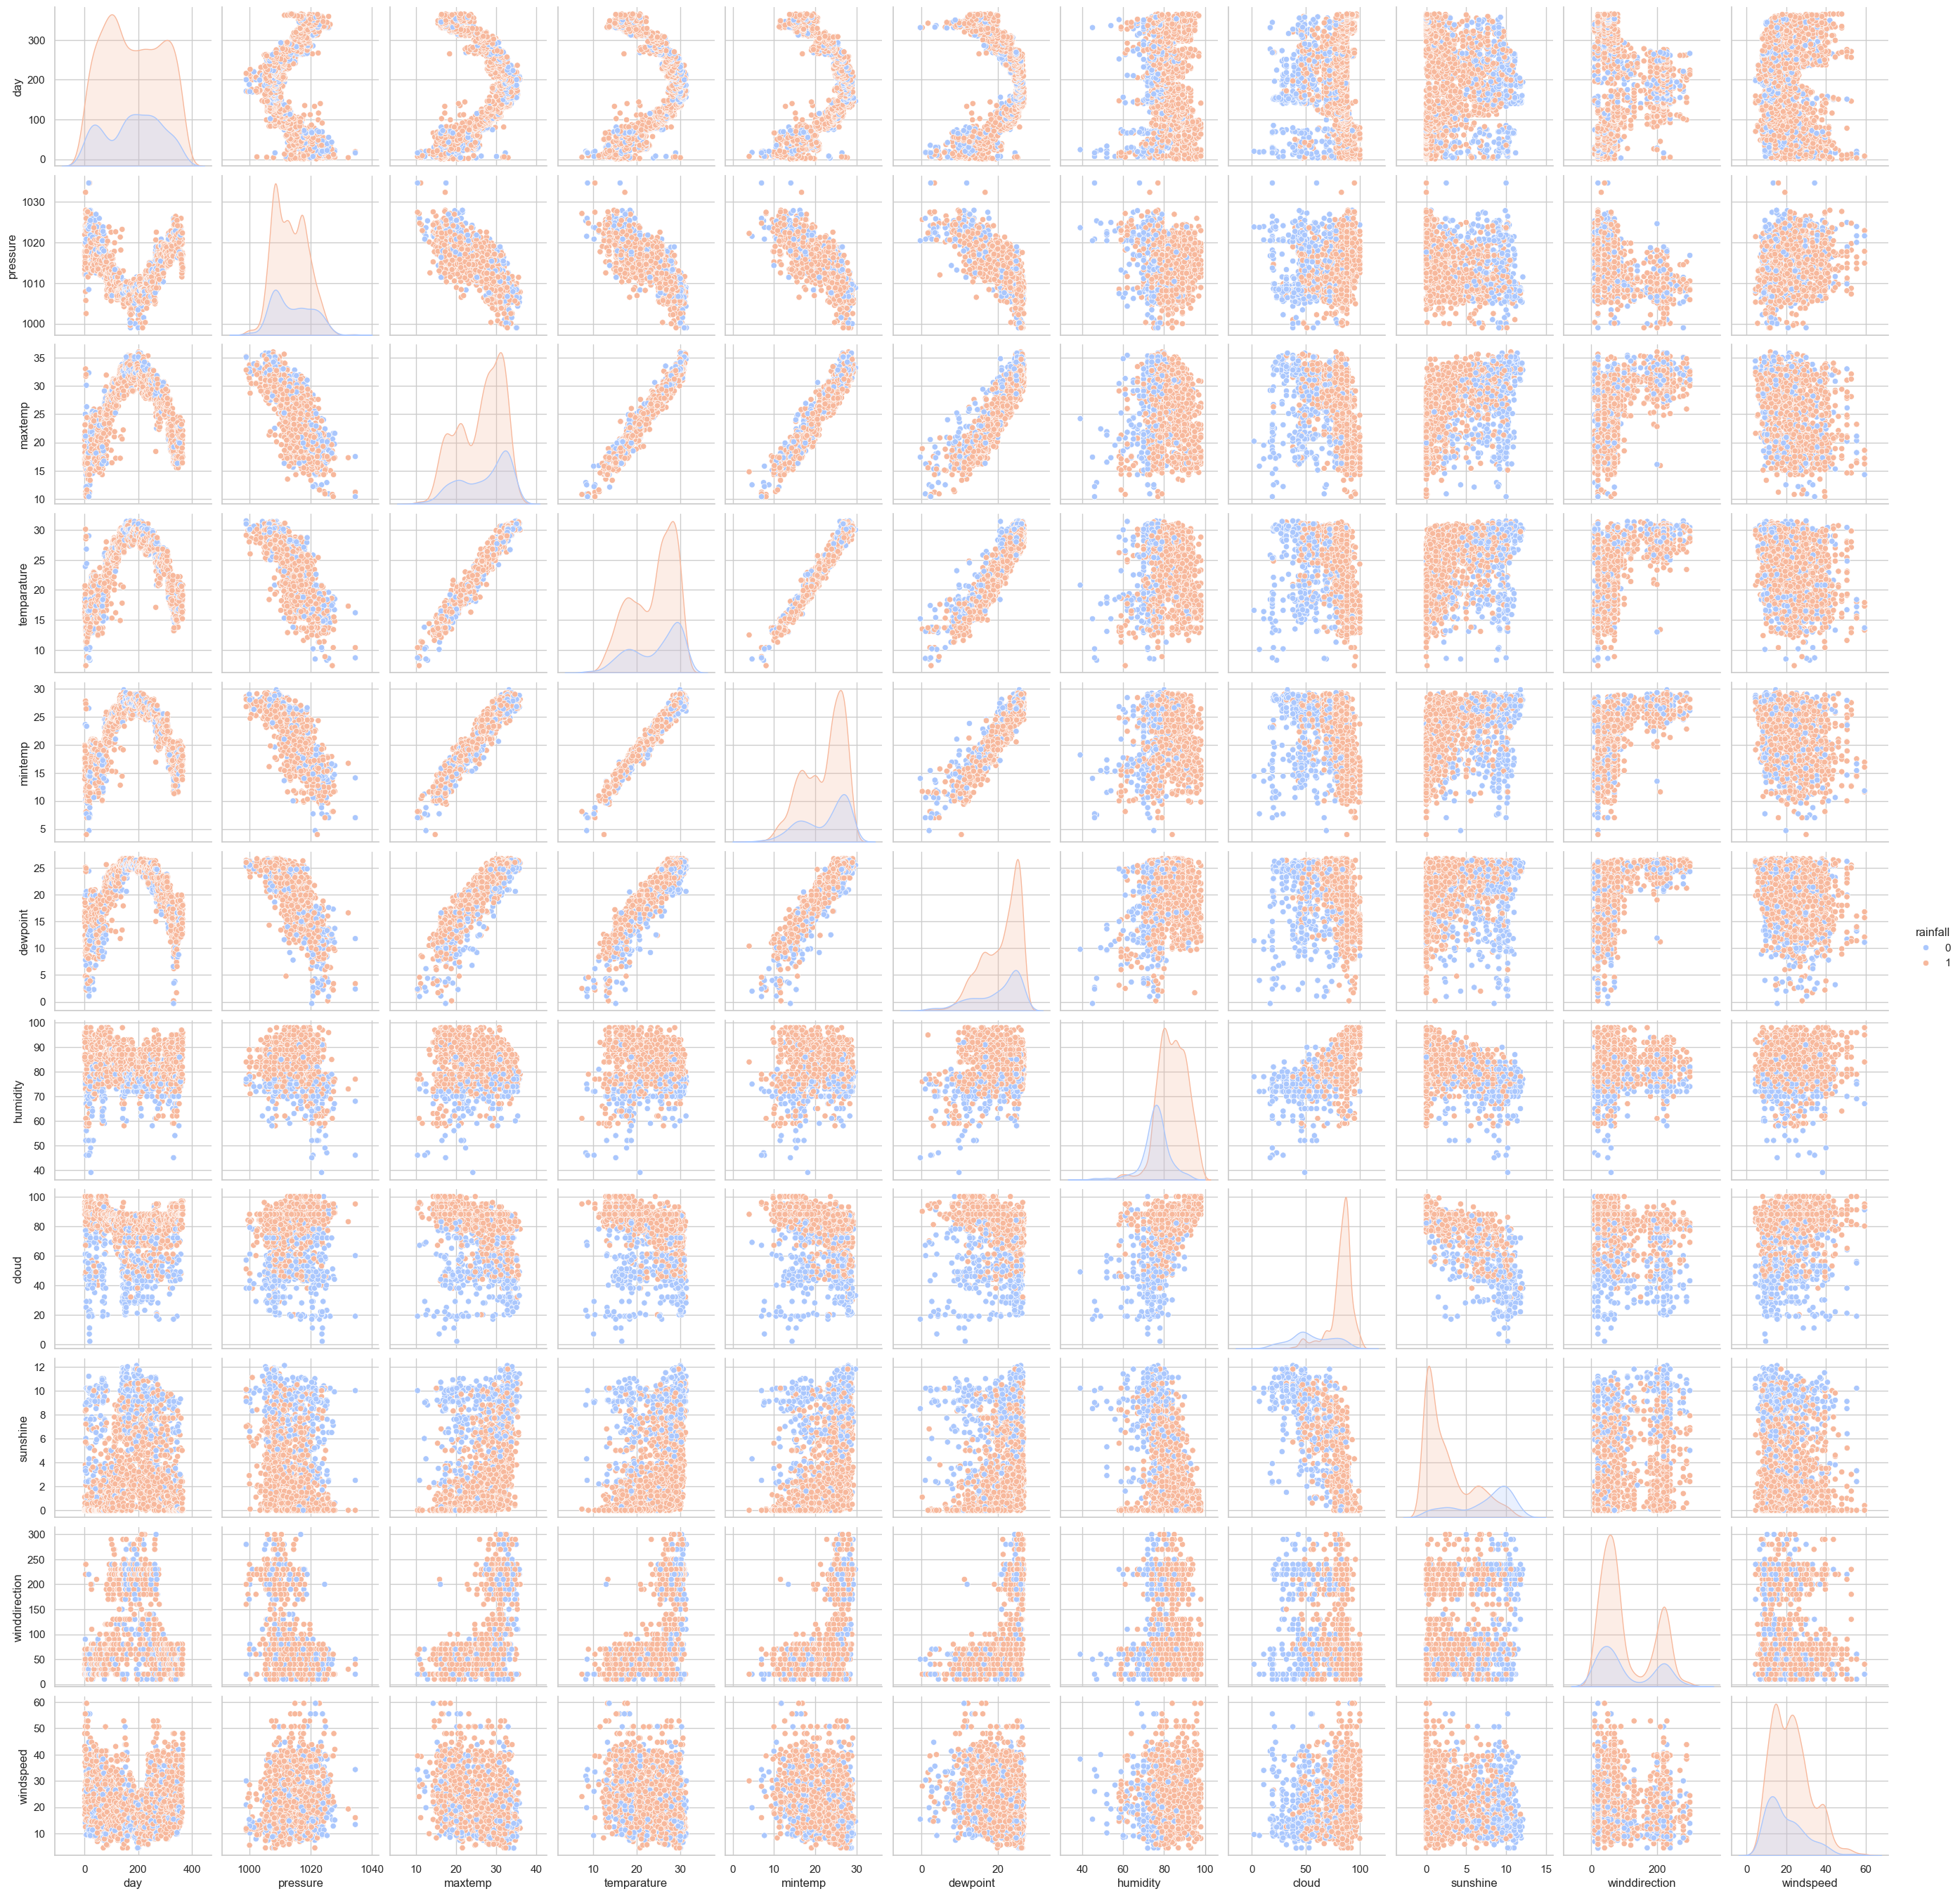

In [99]:
sns.pairplot(train_df[numerical_columns + ['rainfall']], hue='rainfall', palette='coolwarm', diag_kind='kde')
plt.show()

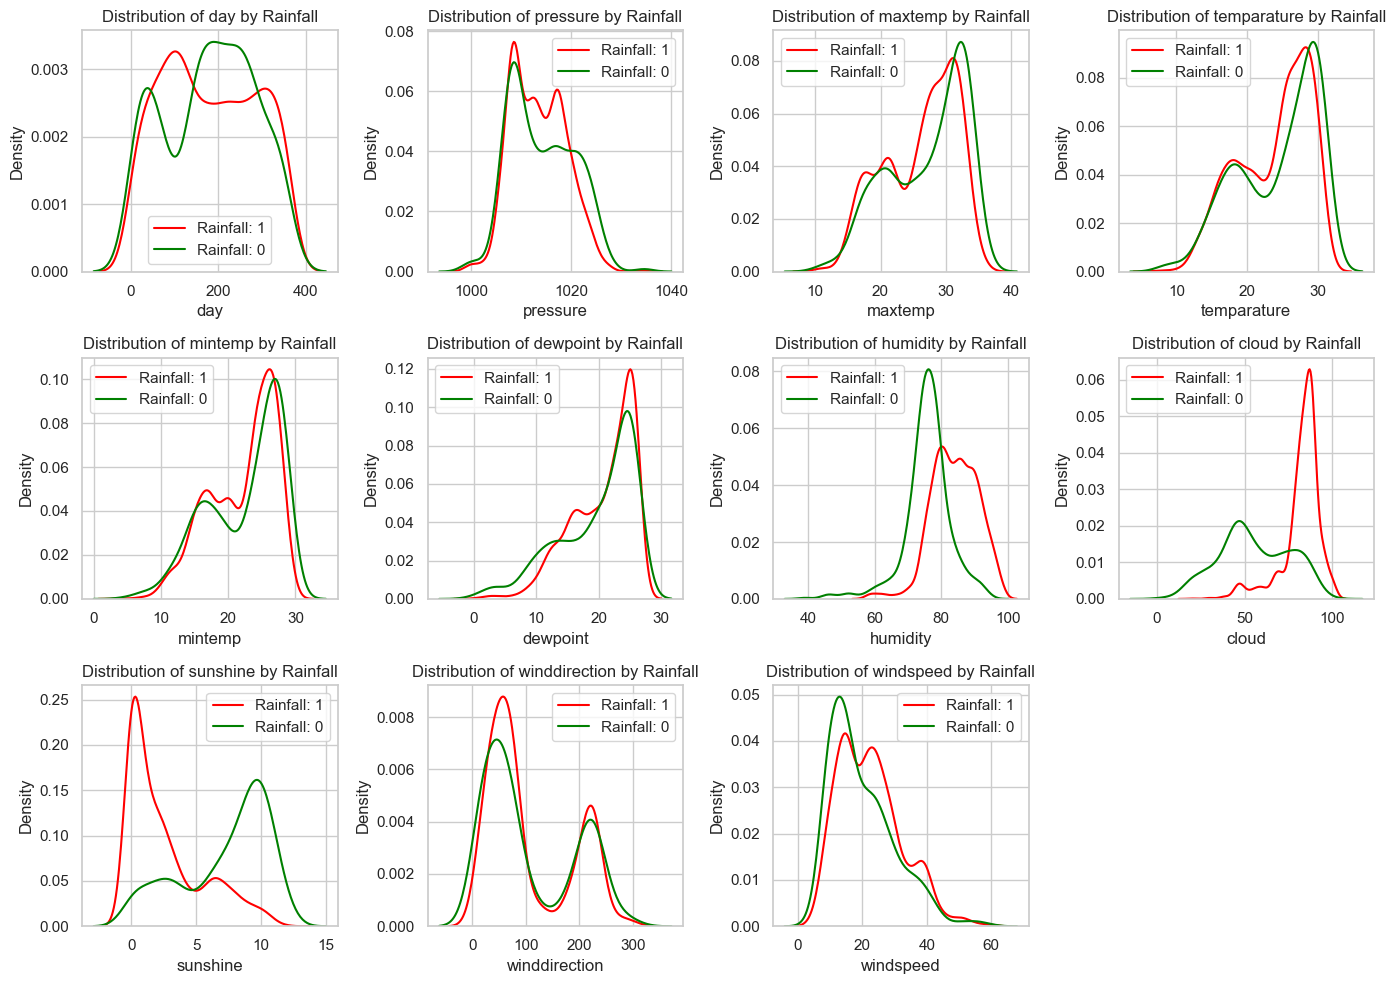

In [105]:
# KDE plot for Feature-Target Relationship
plt.figure(figsize=(14, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 4, i)
    sns.kdeplot(train_df[col][train_df['rainfall'] == 1], color='red', label='Rainfall: 1')
    sns.kdeplot(train_df[col][train_df['rainfall'] == 0], color='green', label='Rainfall: 0')
    plt.title(f'Distribution of {col} by Rainfall')
    plt.legend()
plt.tight_layout()
plt.show()

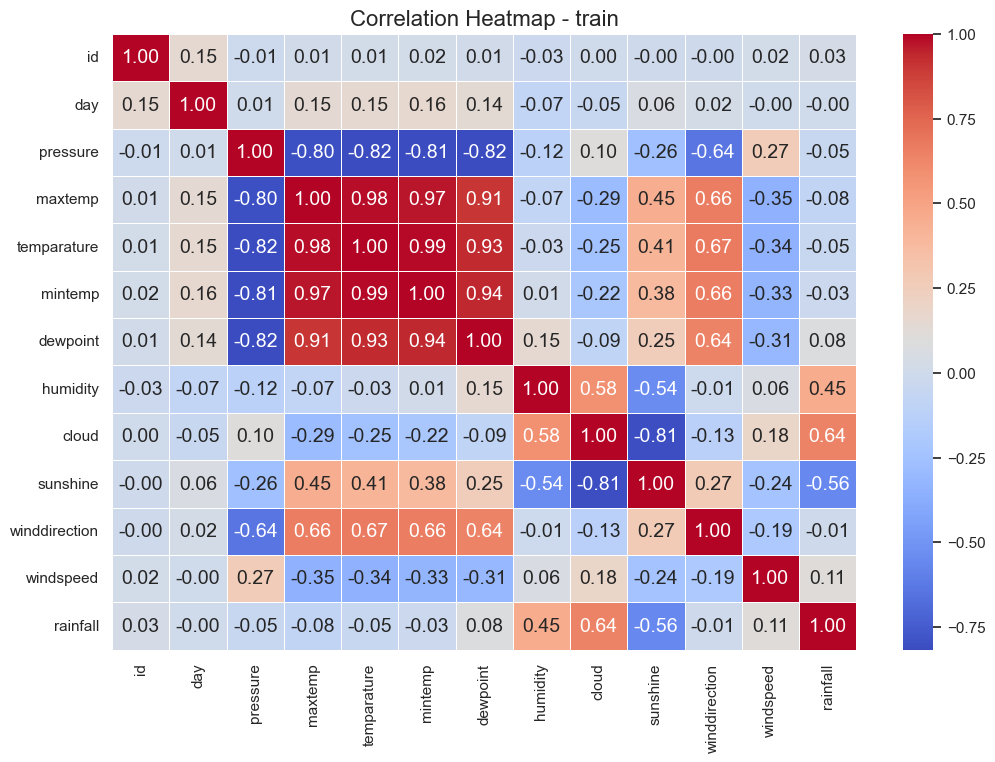

In [117]:
plt.figure(figsize=(12, 8))
corr_matrix = train_copy.corr()
sns.heatmap(corr_matrix, annot=True, annot_kws={"size": 14},cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title(f'Correlation Heatmap - train', fontsize=16)
plt.show()

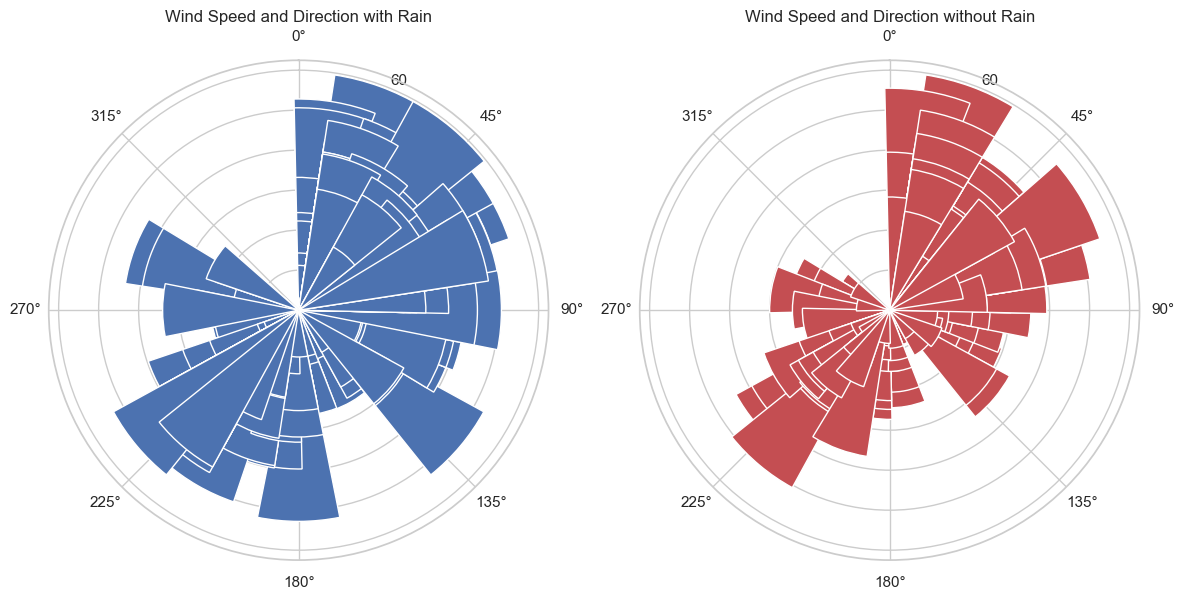

In [149]:
# Filter data based on rainfall
rain_data = train_df[train_df['rainfall'] == 1]
no_rain_data = train_df[train_df['rainfall'] == 0]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(12, 6))

# First wind rose plot (rain)
ax1 = axes[0]
ax1.set_theta_direction(-1)
ax1.set_theta_offset(np.pi / 2.0)
bars1 = ax1.bar(
    np.deg2rad(rain_data['winddirection']),
    rain_data['windspeed'],
    width=np.pi/8,
    bottom=0.0,
    color="b"  
)
ax1.set_title('Wind Speed and Direction with Rain')

# Second wind rose plot (no rain)
ax2 = axes[1]
ax2.set_theta_direction(-1)
ax2.set_theta_offset(np.pi / 2.0)
bars2 = ax2.bar(
    np.deg2rad(no_rain_data['winddirection']),
    no_rain_data['windspeed'],
    width=np.pi/8,
    bottom=0.0,
    color="r"  
)
ax2.set_title('Wind Speed and Direction without Rain')

plt.tight_layout()
plt.show()


In [5]:
test_df = pd.read_csv("test_play.csv")
display(test_df.head())
print(test_df.shape)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


(730, 12)


### Training with XGB and Cat

In [179]:
features_data = train_df.drop(columns=["rainfall", "id"])
print("Features are :",features_data.columns)
print(features_data.shape)
y = train_df["rainfall"]

Features are : Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')
(2190, 11)


In [11]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import xgboost
import catboost
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
print("Using XGBoost version",xgboost.__version__)
print("Using CatBoost version",catboost.__version__)

Using XGBoost version 2.1.3
Using CatBoost version 1.2.7


In [13]:
fold = 15
skf = StratifiedKFold(n_splits=fold, shuffle=True, random_state=700)

auc_scores = []
models = []       # liste pour stocker les modèles

for fold, (train_index, valid_index) in enumerate(skf.split(features_data, y), start=1):
    print("#" * 25)
    print(f"### Fold {fold}")
    print("#" * 25)
    
    features_train = features_data.iloc[train_index].copy()
    y_train = y.iloc[train_index]    
    features_valid = features_data.iloc[valid_index].copy()
    y_valid = y.iloc[valid_index]

    xgb = XGBClassifier(
        device="cuda",
        max_depth=5,  
        colsample_bytree=0.9, 
        subsample=0.9, 
        n_estimators=10_000,  
        learning_rate=0.1, 
        eval_metric="auc",
        verbosity=0
    )

    xgb.fit(features_train, y_train)

    y_valid_proba = xgb.predict_proba(features_valid)[:,1]

    auc = roc_auc_score(y_valid, y_valid_proba)
    auc_scores.append(auc)

    print(f"fold {fold}  XGB: AUC = {auc:.4f}")
    
    models.append(xgb)

#########################
### Fold 1
#########################
fold 1  XGB: AUC = 0.8265
#########################
### Fold 2
#########################
fold 2  XGB: AUC = 0.8864
#########################
### Fold 3
#########################
fold 3  XGB: AUC = 0.8523
#########################
### Fold 4
#########################
fold 4  XGB: AUC = 0.7859
#########################
### Fold 5
#########################
fold 5  XGB: AUC = 0.8235
#########################
### Fold 6
#########################
fold 6  XGB: AUC = 0.8753
#########################
### Fold 7
#########################
fold 7  XGB: AUC = 0.8742
#########################
### Fold 8
#########################
fold 8  XGB: AUC = 0.8918
#########################
### Fold 9
#########################
fold 9  XGB: AUC = 0.8364
#########################
### Fold 10
#########################
fold 10  XGB: AUC = 0.8503
#########################
### Fold 11
#########################
fold 11  XGB: AUC = 0.9169
#################

In [247]:
for fold, (train_index, valid_index) in enumerate(skf.split(features_data, y), start=1):
    print("#" * 25)
    print(f"### Fold {fold}")
    print("#" * 25)
    
    features_train = features_data.iloc[train_index].copy()
    y_train = y.iloc[train_index]    
    features_valid = features_data.iloc[valid_index].copy()
    y_valid = y.iloc[valid_index]

    cat = CatBoostClassifier(
        max_depth=5,  
        random_seed=420, 
        subsample=0.9, 
        n_estimators=10_000,  
        learning_rate=0.9, 
        eval_metric="AUC",
        verbose=0,
        early_stopping_rounds=10
    )

    cat.fit(features_train,y_train)

    y_valid_proba = cat.predict_proba(features_valid)[:,1]

    auc_cat = roc_auc_score(y_valid,y_valid_proba)
    auc_scores.append(auc_cat)

    print(f"fold {fold}  CAT: AUC = {auc_cat:.4f}")

    #print(f"mean of auc for cat is : {np.mean(auc_cat):.4f}")

#########################
### Fold 1
#########################
fold 1  CAT: AUC = 0.8308
#########################
### Fold 2
#########################
fold 2  CAT: AUC = 0.8778
#########################
### Fold 3
#########################
fold 3  CAT: AUC = 0.8422
#########################
### Fold 4
#########################
fold 4  CAT: AUC = 0.7937
#########################
### Fold 5
#########################
fold 5  CAT: AUC = 0.8136
#########################
### Fold 6
#########################
fold 6  CAT: AUC = 0.8374
#########################
### Fold 7
#########################
fold 7  CAT: AUC = 0.8634
#########################
### Fold 8
#########################
fold 8  CAT: AUC = 0.9303
#########################
### Fold 9
#########################
fold 9  CAT: AUC = 0.8058
#########################
### Fold 10
#########################
fold 10  CAT: AUC = 0.8114
#########################
### Fold 11
#########################
fold 11  CAT: AUC = 0.9263
#################

### Optimization of best model

In [151]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.9],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 0.9, 1.0]
}

cat = CatBoostClassifier(
        max_depth=5,  
        random_seed=420, 
        subsample=0.9, 
        n_estimators=10_000,  
        learning_rate=0.9, 
        eval_metric="AUC",
        verbose=0,
        early_stopping_rounds=10
)

grid_search = GridSearchCV(estimator=cat, param_grid=param_grid, scoring='roc_auc', cv=3)
grid_search.fit(features_data, y)
print("Best parameters:", grid_search.best_params_)
print("Best AUC:", grid_search.best_score_)


Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best AUC: 0.8956767676767677


### Features Importances

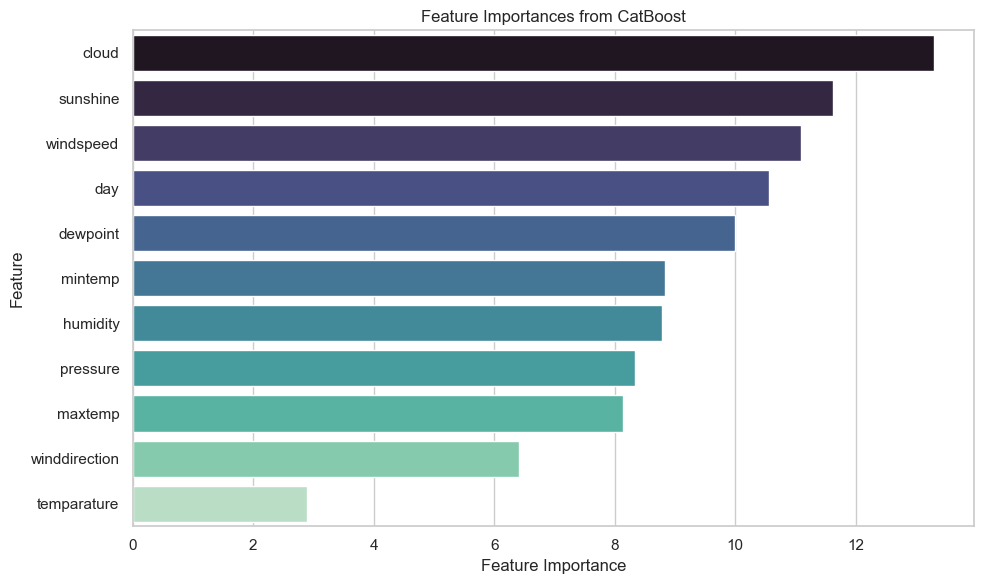

In [187]:
# Ensure the feature importances are 1D and retrieve feature names from features_train
feature_importance = np.atleast_1d(cat.feature_importances_)
features = features_train.columns.tolist()

# Create a DataFrame for plotting the feature importances
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

# Plot the feature importances using a horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="mako")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importances from CatBoost")
plt.tight_layout()
plt.show()

In [157]:
test_df1 = test_df.copy()
features = train_df.drop(columns=["rainfall", "id"], axis=1).columns.tolist()
test_df1=test_df1[features]
y_pred_test = grid_search.predict_proba(test_df1)[:,1]

In [159]:
rainfall_df = pd.DataFrame({"id":test_df["id"],"rainfall":y_pred_test})
rainfall_df
rainfall_df.to_csv("submission_rain.csv",index=False)